[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sterolose/sirius-statistics-2026/blob/main/notebooks/1_distributions.ipynb)

## Семинар 1. Распределения и базовый функционал `scipy`

На данном практикуме познакомимся с `scipy.stats` и поэкспериментируем с генерацией распределений.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
np.random.seed(42)
df = sns.load_dataset("penguins")

Возьмем длины ласт пингвинов вида `Chinstrap`. Зададим нормальное распределение с теми же средним и стандартным отклонением (`ddof=1`). Параметры `loc` и `scale` у `norm` соответствуют этим двум величинам.

In [3]:
flipper = df.loc[df["species"] == "Chinstrap", "flipper_length_mm"].dropna()

mu = flipper.mean()
sigma = flipper.std()
normal = stats.norm(loc=mu, scale=sigma)

mu, sigma

(np.float64(195.8235294117647), 7.131894258578146)

Метод `pdf` возвращает плотность, `cdf` — вероятность $P(X \leq x)$, а `ppf` — квантиль заданного уровня.

In [4]:
threshold = 200
density = normal.pdf(threshold)
probability = normal.cdf(threshold)
quantile = normal.ppf(0.95)

pd.Series({
    "density(200)": density,
    "P(X <= 200)": probability,
    "95% quantile": quantile,
})

,0
density(200),0.047124
P(X <= 200),0.720929
95% quantile,207.554452


Отметим плотность в точке 200, площадь слева от нее и квантиль уровня 0.95.

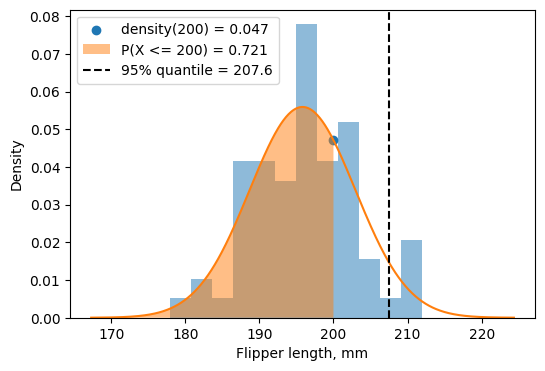

In [5]:
plt.figure(figsize=(6, 4))

plt.hist(flipper, bins=12, density=True, alpha=0.5)


x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
plt.plot(x, normal.pdf(x))

plt.scatter(threshold, density, label=f"density(200) = {density:.3f}")

plt.fill_between(x, normal.pdf(x), where=x <= threshold, alpha=0.5,
                 label=f"P(X <= 200) = {probability:.3f}")

plt.axvline(quantile, color="black", linestyle="--",
            label=f"95% quantile = {quantile:.1f}")

plt.xlabel("Flipper length, mm")
plt.ylabel("Density")

plt.legend()
plt.show()

Плотность в точке — не вероятность: вероятность для непрерывной величины соответствует площади под кривой. Вероятность попасть в интервал можно найти как разность значений `cdf`.

In [6]:
normal.cdf(205) - normal.cdf(195)

np.float64(0.4468614294126622)

Метод `rvs` генерирует случайную выборку из заданного распределения.

In [7]:
normal.rvs(size=10)

array([199.36604223, 194.83744304, 200.44277558, 206.6856173 ,
       194.1535723 , 194.15368939, 207.08630822, 201.29679275,
       192.47528773, 199.69301027])

### Задание 1

Сгенерируйте по 1000 наблюдений из распределений `norm`, `laplace`, `uniform`, `lognorm`, `expon` и `loguniform`. Параметры выберите самостоятельно. Постройте гистограммы на сетке 2 × 3 и добавьте теоретические плотности с помощью `plt.plot`.

Обратите внимание, что набор и смысл параметров у разных распределений отличаются от нормального: например, у `norm` используются `loc` и `scale`, у `lognorm` дополнительно задаётся параметр формы `s`, у `loguniform` — границы `a` и `b`.

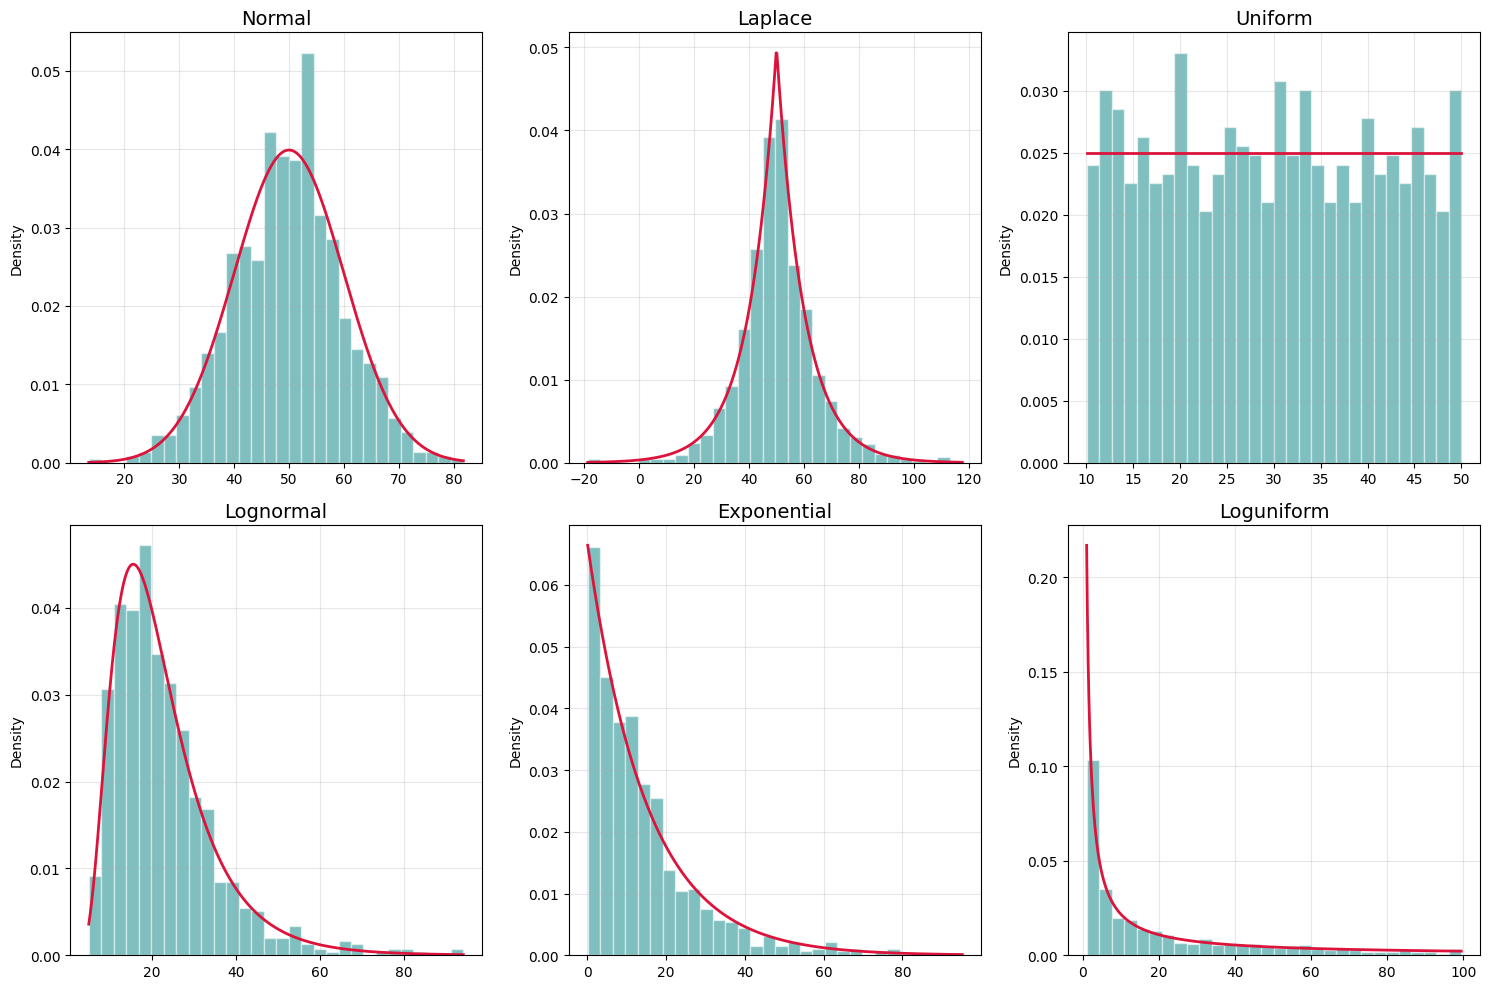

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)
size = 1000

models = {
    "Normal": stats.norm(loc=50, scale=10),
    "Laplace": stats.laplace(loc=50, scale=10),
    "Uniform": stats.uniform(loc=10, scale=40),
    "Lognormal": stats.lognorm(s=0.5, loc=0, scale=np.exp(3)),
    "Exponential": stats.expon(loc=0, scale=15),
    "Loguniform": stats.loguniform(a=1, b=100)
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (name, dist) in zip(axes, models.items()):
  data = dist.rvs(size=size, random_state=rng)
  ax.hist(data, bins=30, density=True, alpha=0.5, color="teal", edgecolor="white")
  x_axis = np.linspace(data.min(), data.max(), 500)
  ax.plot(x_axis, dist.pdf(x_axis), color="crimson", linewidth=2)
  ax.set_title(name, fontsize=14)
  ax.set_ylabel("Density")
  ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Задание 2

Сгенерируйте 1000 выборок размера 100 из нормального распределения со стандартным отклонением 2. Для каждой выборки вычислите дисперсию и стандартное отклонение с `ddof=0` и `ddof=1`. Рассчитайте среднее отклонение каждой оценки от истинного значения: оценка минус истинное значение, без модуля. Устраняет ли `ddof=1` смещение в обоих случаях?

In [17]:
import numpy as np
import scipy.stats as stats

num_samples = 1000
sample_size = 100
true_std = 2.0
true_var = true_std**2

#rng = np.random.default_rng(42) ВОЗНИК ВОПРОС!!!
dist = stats.norm(loc=0, scale=true_std)
samples = dist.rvs(size=(num_samples, sample_size), random_state=42)

var_ddof0 = np.var(samples, axis=1, ddof=0)
var_ddof1 = np.var(samples, axis=1, ddof=1)

std_ddof0 = np.std(samples, axis=1, ddof=0)
std_ddof1 = np.std(samples, axis=1, ddof=1)

bias_var_ddof0 = np.mean(var_ddof0 - true_var)
bias_var_ddof1 = np.mean(var_ddof1 - true_var)

bias_std_ddof0 = np.mean(std_ddof0 - true_std)
bias_std_ddof1 = np.mean(std_ddof1 - true_std)

print(f"Истинная дисперсия: {true_var}")
print(f"Истинное станд. отклонение: {true_std}")

print(f"Смещение дисперсии ddof=0: {bias_var_ddof0:+.4f} (занижает истинное значение, около -0,04, что следует из формулы)")
print(f"Смещение дисперсии ddof=1: {bias_var_ddof1:+.4f} (стремится к 0)")

print(f"Смещение станд. отклонения ddof=0: {bias_std_ddof0:+.4f} (смещено вниз)")
print(f"Смещение станд. отклонения ddof=1: {bias_std_ddof1:+.4f} (смещение сильно меньше, но всё же есть)")


Истинная дисперсия: 4.0
Истинное станд. отклонение: 2.0
Смещение дисперсии ddof=0: -0.0363 (занижает истинное значение, около -0,04, что следует из формулы)
Смещение дисперсии ddof=1: +0.0038 (стремится к 0)
Смещение станд. отклонения ddof=0: -0.0140 (смещено вниз)
Смещение станд. отклонения ddof=1: -0.0040 (смещение сильно меньше, но всё же есть)


### Задание 3

Для каждого размера выборки от 1 до 100 сгенерируйте 1000 выборок из экспоненциального распределения и вычислите их средние. Рассчитайте асимметрию полученных средних с помощью `stats.skew`. Постройте её зависимость от размера выборки и добавьте теоретическую кривую $(2/\sqrt{n})$. Для размеров 1, 10 и 100 постройте гистограммы стандартизованных средних и добавьте плотность стандартного нормального распределения.

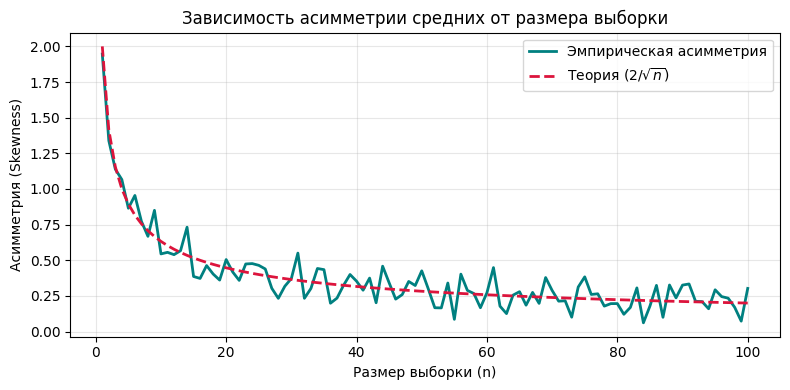

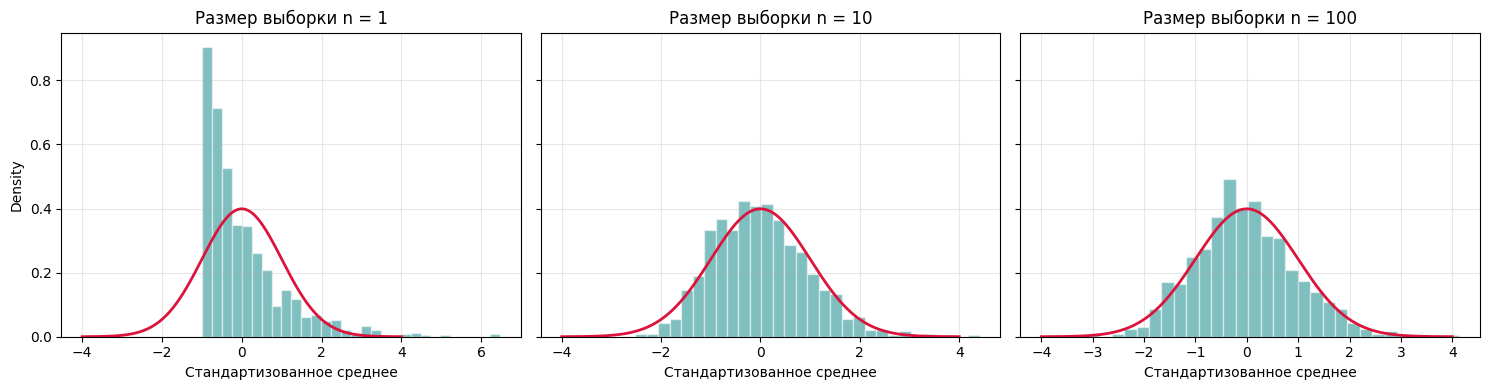

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

rng = np.random.default_rng(42)
num_samples = 1000
sample_sizes = np.arange(1, 101)
exp_dist = stats.expon()
emp_skew = []
saved_means = {}

for n in sample_sizes:
    samples = exp_dist.rvs(size=(num_samples, n), random_state=rng)
    sample_means = np.mean(samples, axis=1)
    emp_skew.append(stats.skew(sample_means))
    if n in [1, 10, 100]:
        # Стандартизация: (X - E[X]) / STD[X]
        # Для среднего экспоненциального: E = 1, STD = 1 / sqrt(n)
        standardized = (sample_means - 1.0) / (1.0 / np.sqrt(n))
        saved_means[n] = standardized

fig1, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(sample_sizes, emp_skew, color="teal", linewidth=2, label="Эмпирическая асимметрия")


theo_skew = 2.0 / np.sqrt(sample_sizes)
ax1.plot(sample_sizes, theo_skew, color="crimson", linewidth=2, linestyle="--", label=r"Теория ($2/\sqrt{n}$)")

ax1.set_title("Зависимость асимметрии средних от размера выборки")
ax1.set_xlabel("Размер выборки (n)")
ax1.set_ylabel("Асимметрия (Skewness)")
ax1.grid(alpha=0.3)
ax1.legend()
plt.tight_layout()

fig2, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
norm_dist = stats.norm(loc=0, scale=1)
x_axis = np.linspace(-4, 4, 500)
pdf_y = norm_dist.pdf(x_axis)

for ax, n in zip(axes, [1, 10, 100]):
    ax.hist(saved_means[n], bins=30, density=True, alpha=0.5, color="teal", edgecolor="white")
    ax.plot(x_axis, pdf_y, color="crimson", linewidth=2)

    ax.set_title(f"Размер выборки n = {n}")
    ax.set_xlabel("Стандартизованное среднее")
    if n == 1:
        ax.set_ylabel("Density")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
